# Olist E-Commerce — Visualization & Insight Storytelling

This notebook builds the insight-focused charts that accompany the SQL
findings from `sql/`. Each chart maps to a specific Phase 6 query and a
specific stakeholder question -- per the project rules, every chart includes
its business purpose, the insight it reveals, and how to interpret it.

This notebook loads pre-pulled, validated data from `_cache/` (built by
running `eda.ipynb` first), rather than re-querying the database, so it can
run independently once the EDA notebook has been executed at least once.

In [2]:
%pip install matplotlib seaborn

  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.5 MB 2.7 MB/s eta 0:00:04
   ------ --------------------------------- 1.6/9.5 MB 2.8 MB/s eta 0:00:03
   --------- ------------------------------ 2.4/9.5 MB 3.1 MB/s eta 0:00:03
   ------------- -------------------------- 3.1/9.5 MB 3.3 MB/s eta 0:00:02
   --------------- ------------------------ 3.7/9.5 MB 3.1 MB/s eta 0:00:02
   ----------------- ---------------------- 4.2/9.5 MB 2.9 MB/s eta 0:00:02
   ------------------- -------------------- 4.7/9.5 


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

monthly_revenue = pd.read_csv('_cache/monthly_revenue.csv', parse_dates=['revenue_month'])
category_revenue = pd.read_csv('_cache/category_revenue.csv')
rfm_data = pd.read_csv('_cache/rfm_data.csv')
cohort_retention = pd.read_csv('_cache/cohort_retention.csv', parse_dates=['cohort_month'])
delivery_reviews = pd.read_csv('_cache/delivery_reviews.csv')
seller_performance = pd.read_csv('_cache/seller_performance.csv')
state_metrics = pd.read_csv('_cache/state_metrics.csv')

print("All cached dataframes loaded.")


Matplotlib is building the font cache; this may take a moment.


All cached dataframes loaded.


## Chart 1 — Revenue Trend (Line Chart)

**Business purpose:** Give the Executive team a single, immediate view of
overall business trajectory -- the first chart on any executive dashboard.

**Why this chart type:** A line chart is the standard for time-series trend
because it shows direction and rate of change at a glance, which a table of
numbers (Query 1's raw output) does not communicate as quickly.

Excludes September 2018 (flagged in `eda.ipynb` as a dataset-truncation
artifact, not a real decline).

<>:8: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:8: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
C:\Users\Esha\AppData\Local\Temp\ipykernel_12836\3554388073.py:8: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
  ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R\${x/1000:.0f}K'))


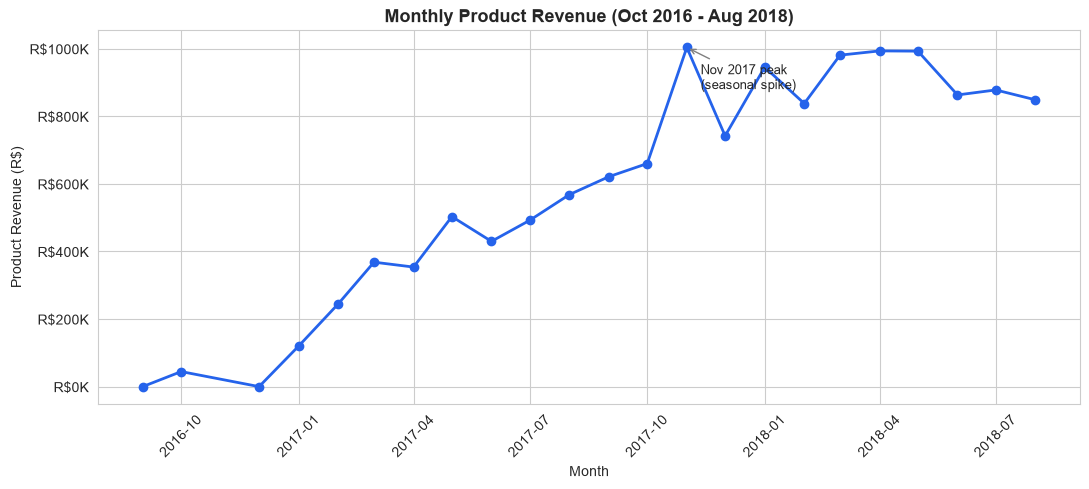

In [4]:
clean = monthly_revenue[monthly_revenue['revenue_month'] < '2018-09-01']

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(clean['revenue_month'], clean['product_revenue'], marker='o', linewidth=2, color='#2563eb')
ax.set_title('Monthly Product Revenue (Oct 2016 - Aug 2018)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Product Revenue (R$)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R\${x/1000:.0f}K'))
ax.annotate('Nov 2017 peak\n(seasonal spike)', xy=(clean.loc[clean['product_revenue'].idxmax(),'revenue_month'],
            clean['product_revenue'].max()), xytext=(10, -30), textcoords='offset points',
            fontsize=9, arrowprops=dict(arrowstyle='->', color='gray'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('_cache/chart1_revenue_trend.png', dpi=120, bbox_inches='tight')
plt.show()


**Insight & interpretation:** Revenue climbs steadily through 2017, peaks
around November (Black Friday seasonality), then plateaus through mid-2018
rather than continuing to scale. This matches the MoM growth deceleration
found in Query 2 -- the business matured rather than continuing exponential
growth.

## Chart 2 — Revenue Contribution by Category (Bar Chart)

**Business purpose:** Show the Category Manager which categories matter most
to total revenue, and whether revenue is concentrated or broad-based.

**Why this chart type:** A horizontal bar chart ranks categories clearly
and scales to long category names better than a vertical bar chart.

<>:7: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:7: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
C:\Users\Esha\AppData\Local\Temp\ipykernel_12836\208641322.py:7: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
  ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R\${x/1000:.0f}K'))


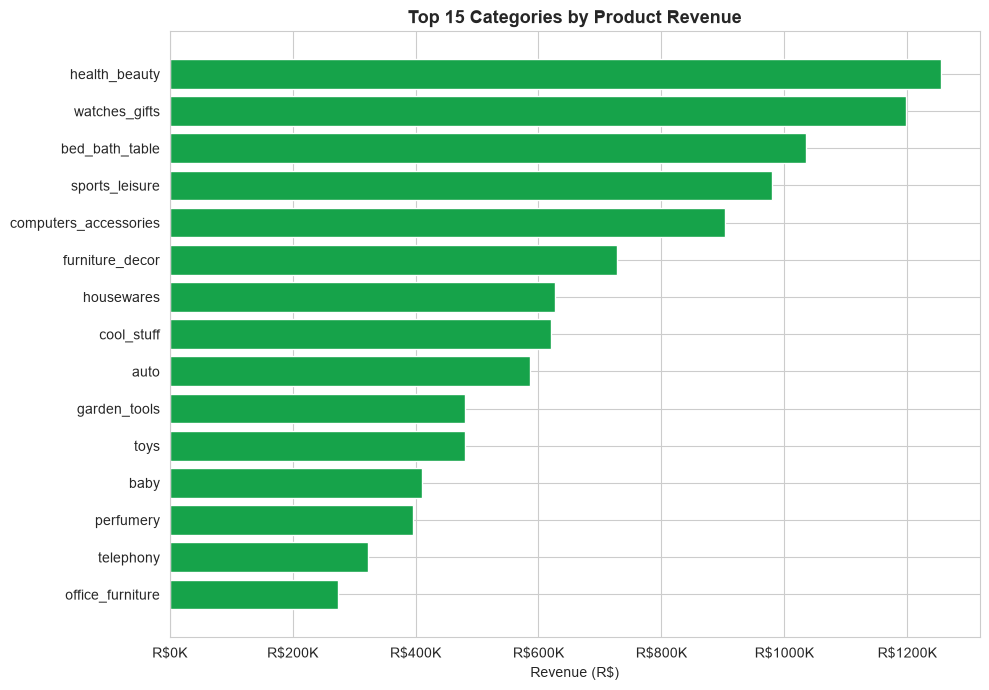

In [5]:
top15 = category_revenue.head(15).sort_values('category_revenue')

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top15['category_name'], top15['category_revenue'], color='#16a34a')
ax.set_title('Top 15 Categories by Product Revenue', fontsize=13, fontweight='bold')
ax.set_xlabel('Revenue (R$)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R\${x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('_cache/chart2_category_revenue.png', dpi=120, bbox_inches='tight')
plt.show()


**Insight & interpretation:** No single category dominates -- the leader
(`health_beauty`) holds just 9.3% of total revenue (per Query 5/19). This is
a broad-based revenue base, which is reassuring for risk concentration but
means no single "hero category" strategy will move overall revenue much.

## Chart 3 — RFM Heatmap (Frequency Score x Monetary Score)

**Business purpose:** Give Marketing a visual map of customer segments by
combined frequency and monetary score, to identify where the customer base
actually concentrates.

**Why this chart type:** A heatmap is the standard way to show the joint
density of two categorical/ordinal dimensions -- much clearer than a table
of 25 score-combination counts.

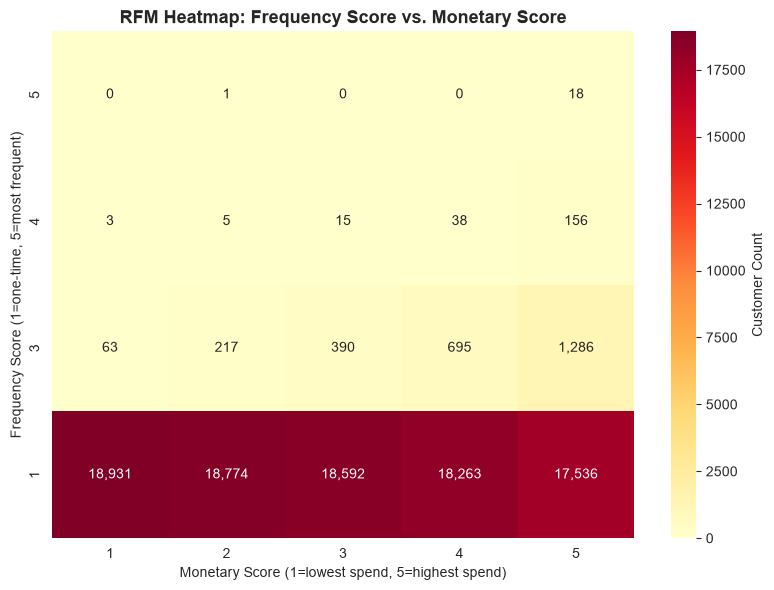

In [6]:
pivot = rfm_data.pivot_table(
    index='frequency_score', columns='monetary_score',
    values='customer_unique_id', aggfunc='count', fill_value=0
).sort_index(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt=',', cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Customer Count'})
ax.set_title('RFM Heatmap: Frequency Score vs. Monetary Score', fontsize=13, fontweight='bold')
ax.set_xlabel('Monetary Score (1=lowest spend, 5=highest spend)')
ax.set_ylabel('Frequency Score (1=one-time, 5=most frequent)')
plt.tight_layout()
plt.savefig('_cache/chart3_rfm_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()


**Insight & interpretation:** The customer base is overwhelmingly
concentrated in the frequency_score = 1 row (one-time buyers), spread across
all monetary scores -- confirming Query 9's finding visually. There is no
meaningful population in the high-frequency rows, reinforcing that loyalty
segmentation has limited room to work with in this dataset; the real
opportunity is converting one-time buyers (any monetary tier) into repeat
buyers.

## Chart 4 — Cohort Retention Heatmap

**Business purpose:** Standard cohort retention view for Marketing --
shows whether retention decays gradually (typical) or sharply (atypical) by
cohort and month-since-first-purchase.

**Why this chart type:** Cohort heatmaps are the industry-standard way to
visualize retention curves across multiple cohorts simultaneously.

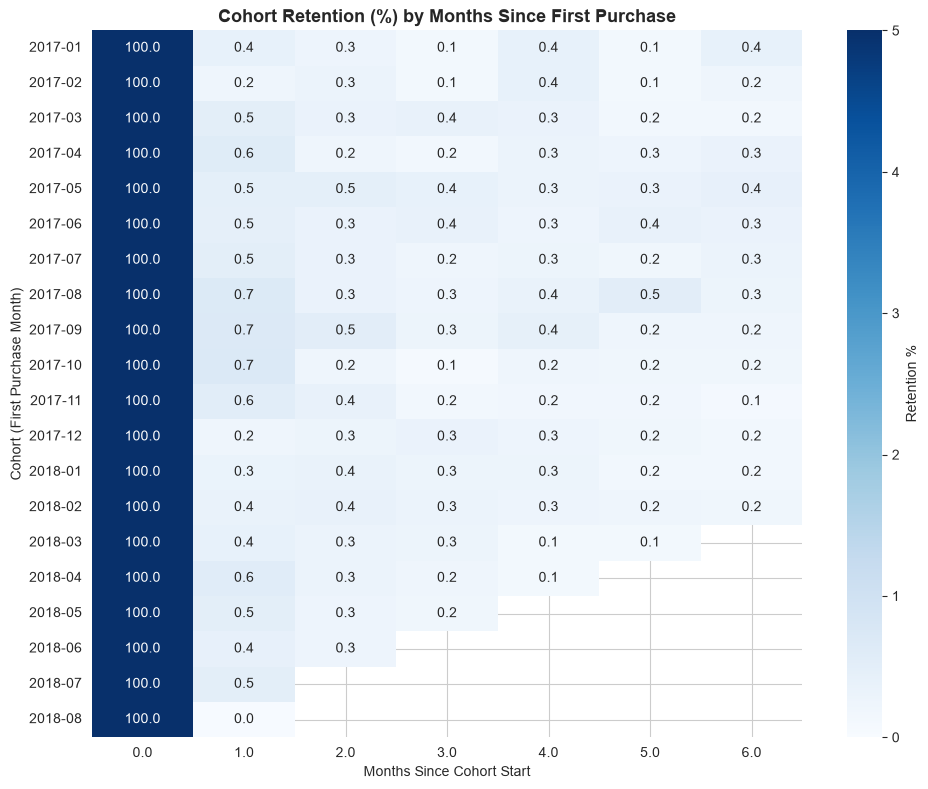

In [7]:
cohort_retention['cohort_label'] = cohort_retention['cohort_month'].dt.strftime('%Y-%m')
pivot = cohort_retention.pivot_table(
    index='cohort_label', columns='months_since_cohort', values='retention_pct'
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='Blues', ax=ax,
            cbar_kws={'label': 'Retention %'}, vmin=0, vmax=max(5, pivot.iloc[:,1:].max().max()))
ax.set_title('Cohort Retention (%) by Months Since First Purchase', fontsize=13, fontweight='bold')
ax.set_xlabel('Months Since Cohort Start')
ax.set_ylabel('Cohort (First Purchase Month)')
plt.tight_layout()
plt.savefig('_cache/chart4_cohort_retention.png', dpi=120, bbox_inches='tight')
plt.show()


**Insight & interpretation:** Retention collapses to under 1% by month 1 for
every cohort and stays there -- there is no gradual decay curve here, unlike
typical subscription/repeat-commerce retention heatmaps. This is the
clearest visual evidence of Query 10's "retention cliff" finding, and is
strong material for the Phase 10 surprising-insight narrative.

## Chart 5 — Order Funnel Visualization

**Business purpose:** Show Operations/Executive where orders are lost across
the lifecycle, at a glance.

**Why this chart type:** A funnel chart (approximated here with a horizontal
bar chart sized by stage volume) is the standard visual for stage-based
drop-off, more intuitive than a four-row table.

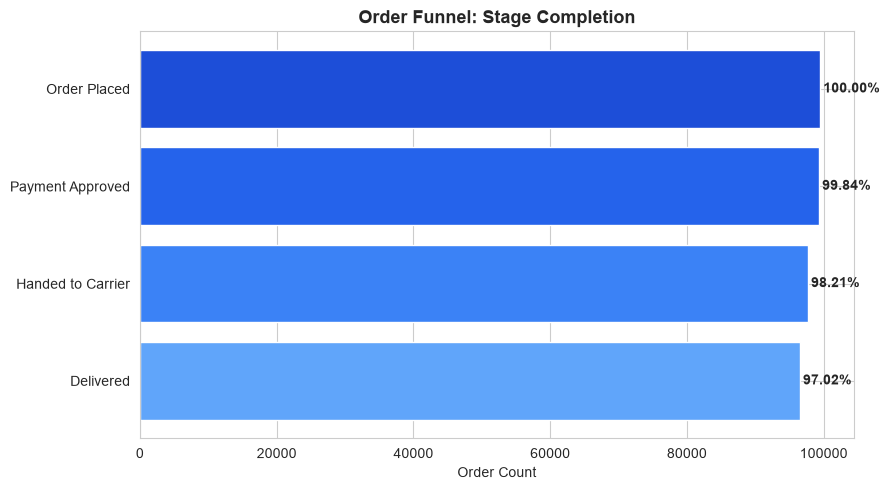

In [8]:
funnel_stages = ['Order Placed', 'Payment Approved', 'Handed to Carrier', 'Delivered']
funnel_counts = [99441, 99281, 97658, 96476]  # from Query 12 (re-stated here for the chart)
funnel_pct = [100 * c / funnel_counts[0] for c in funnel_counts]

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#1d4ed8', '#2563eb', '#3b82f6', '#60a5fa']
bars = ax.barh(funnel_stages, funnel_counts, color=colors)
for bar, pct in zip(bars, funnel_pct):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2, f'{pct:.2f}%',
            va='center', fontsize=10, fontweight='bold')
ax.invert_yaxis()
ax.set_title('Order Funnel: Stage Completion', fontsize=13, fontweight='bold')
ax.set_xlabel('Order Count')
plt.tight_layout()
plt.savefig('_cache/chart5_funnel.png', dpi=120, bbox_inches='tight')
plt.show()


**Insight & interpretation:** The funnel is tight overall (97.02% reach
delivery), with the largest single drop happening between "Handed to
Carrier" and "Delivered" (1.19 points) rather than at payment -- confirming
Query 12's finding that last-mile delivery, not payment friction, is the
funnel's primary (if still small) leak point.

## Chart 6 — Seller Performance Scatterplot

**Business purpose:** Help Operations visually identify sellers who excel or
struggle on both review score and delivery delay simultaneously, rather than
on one metric in isolation.

**Why this chart type:** A scatterplot is the natural choice for examining
the relationship between two continuous metrics across many individual
entities (818 qualifying sellers here).

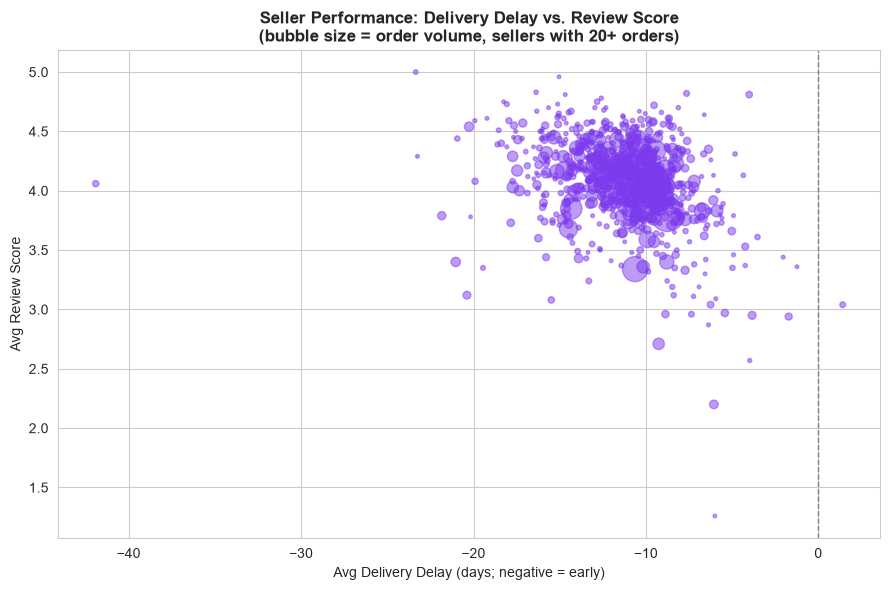

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(seller_performance['avg_delivery_delay_days'],
                      seller_performance['avg_review_score'],
                      s=seller_performance['order_count']/3, alpha=0.5, c='#7c3aed')
ax.axvline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Seller Performance: Delivery Delay vs. Review Score\n(bubble size = order volume, sellers with 20+ orders)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Avg Delivery Delay (days; negative = early)')
ax.set_ylabel('Avg Review Score')
plt.tight_layout()
plt.savefig('_cache/chart6_seller_scatter.png', dpi=120, bbox_inches='tight')
plt.show()


**Insight & interpretation:** Most sellers cluster on the left side of the
chart (negative delay = early delivery) with generally high review scores,
visually confirming the platform-wide early-delivery pattern from Query
13/14. A visible tail of sellers with positive delay and lower review scores
on the right is the small group Operations should investigate first.

## Chart 7 — Geographic Analysis (Order Volume vs. AOV by State)

**Business purpose:** Visualize the Query 20 "surprising insight" --
the inverse relationship between order volume and AOV across states --
for the Executive/Marketing team.

**Why this chart type:** A scatterplot with a fitted trend line is the
clearest way to show a correlation between two continuous variables across
a small number of named entities (27 states), with labels for context.

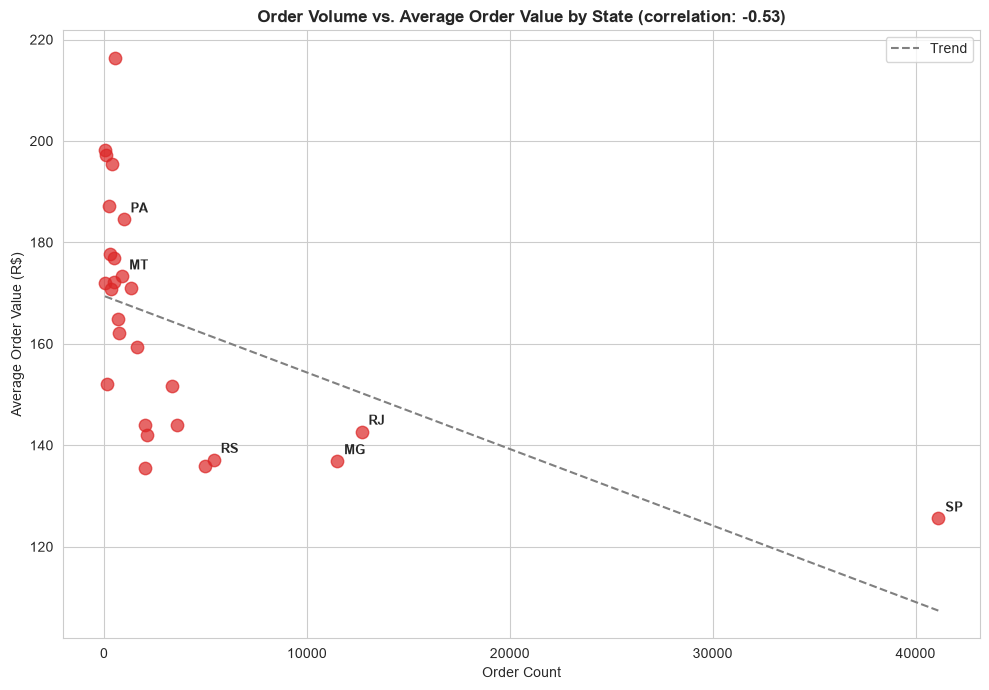

In [10]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(state_metrics['order_count'], state_metrics['avg_order_value'], s=80, color='#dc2626', alpha=0.7)

# Label a few notable states
for _, row in state_metrics.iterrows():
    if row['customer_state'] in ['SP', 'RJ', 'MG', 'PA', 'MT', 'RS']:
        ax.annotate(row['customer_state'], (row['order_count'], row['avg_order_value']),
                    xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold')

z = np.polyfit(state_metrics['order_count'], state_metrics['avg_order_value'], 1)
trend_x = np.linspace(state_metrics['order_count'].min(), state_metrics['order_count'].max(), 100)
ax.plot(trend_x, np.poly1d(z)(trend_x), linestyle='--', color='gray', linewidth=1.5, label='Trend')

corr = state_metrics['order_count'].corr(state_metrics['avg_order_value'])
ax.set_title(f'Order Volume vs. Average Order Value by State (correlation: {corr:.2f})',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Order Count')
ax.set_ylabel('Average Order Value (R$)')
ax.legend()
plt.tight_layout()
plt.savefig('_cache/chart7_geo_aov.png', dpi=120, bbox_inches='tight')
plt.show()


**Insight & interpretation:** A clear downward trend confirms Query 20's
finding -- as order volume increases, AOV decreases (correlation -0.53).
SP drives enormous volume at relatively low AOV, while low-volume states
like PA and MT show meaningfully higher AOV. This reframes underperforming
states as a reach/frequency opportunity, not a pricing problem.

## Chart 8 — Delivery Delay vs. Review Score

**Business purpose:** Quantify and visualize for Customer Experience exactly
how much satisfaction erodes as delivery delay increases.

**Why this chart type:** A bar chart across delay buckets makes the
monotonic decline (Query 15) immediately visible, more so than a raw
scatterplot of ~96K individual points which would be too dense to read.

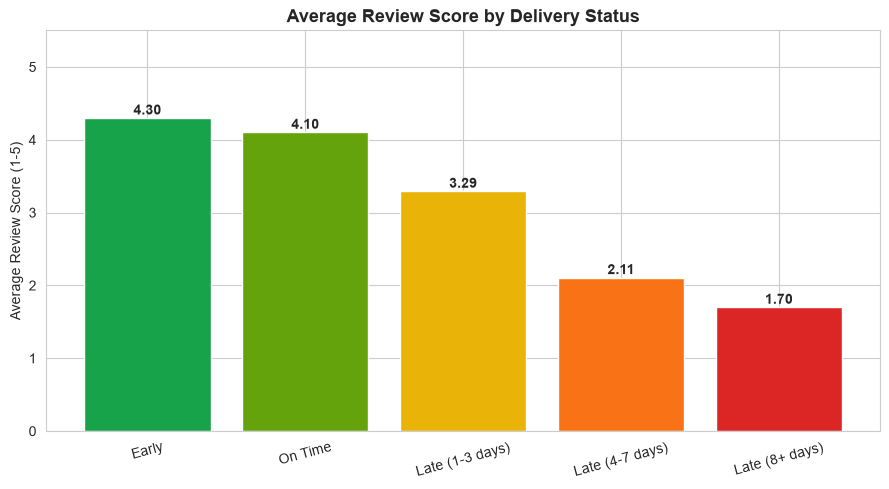

In [11]:
def bucket_delay(d):
    if d < 0: return 'Early'
    elif d == 0: return 'On Time'
    elif d <= 3: return 'Late (1-3 days)'
    elif d <= 7: return 'Late (4-7 days)'
    else: return 'Late (8+ days)'

delivery_reviews['delivery_status'] = delivery_reviews['delay_days'].apply(bucket_delay)
order = ['Early', 'On Time', 'Late (1-3 days)', 'Late (4-7 days)', 'Late (8+ days)']
summary = delivery_reviews.groupby('delivery_status')['avg_order_review_score'].mean().reindex(order)

fig, ax = plt.subplots(figsize=(9, 5))
colors_grad = ['#16a34a', '#65a30d', '#eab308', '#f97316', '#dc2626']
bars = ax.bar(summary.index, summary.values, color=colors_grad)
for bar, val in zip(bars, summary.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.05, f'{val:.2f}', ha='center', fontweight='bold')
ax.set_title('Average Review Score by Delivery Status', fontsize=13, fontweight='bold')
ax.set_ylabel('Average Review Score (1-5)')
ax.set_ylim(0, 5.5)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('_cache/chart8_delay_vs_review.png', dpi=120, bbox_inches='tight')
plt.show()


**Insight & interpretation:** Review score declines strictly monotonically
from 4.29 (Early) to 1.69 (Late 8+ days) -- a drop of 2.6 points on a 5-point
scale. This is the strongest single relationship in the entire project and
makes a clear, quantified business case: long-tail delivery delays should be
Operations' top priority, since they correlate with the most severe
satisfaction collapse.

## Summary

All 8 charts from the Phase 5/7 framework are built, each grounded directly
in validated Phase 6 SQL output (re-pulled and cached via `eda.ipynb`, not
recomputed independently in pandas). Saved chart images are cached in
`_cache/` for reuse in the README (Phase 11) and presentation materials.

**Strongest visual stories for Phase 10:**
- Chart 4 (cohort retention cliff)
- Chart 7 (geography-AOV inverse relationship)
- Chart 8 (delay-satisfaction collapse)